# Driver/Rider Simulation - Updated Parameters

## Setup

#### Installing necessary packages

In [5]:
!pip install pandas
!pip install openpyxl
!pip install seaborn
!pip install scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [6]:
import pandas as pd
import importlib
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Importing data and python files

In [7]:
df_drivers = pd.read_excel("drivers.xlsx")
df_riders = pd.read_excel("riders.xlsx")

In [8]:
import sim
import rev_sim
import dat
import eval

Let's look at the data structure of each driver and rider data

In [9]:
df_drivers.head()

,id,arrival_time,offline_time,initial_location,current_location,status,arrival_datetime,offline_datetime
0,1,5.011975,11.638223,"(0.7897740952818868, 8.194226996886005)","(13.492895938215721, 17.375090044074234)",offline,2025-12-01 13:00:43.110,2025-12-01 19:38:17.601
1,2,5.557763,11.732854,"(4.600342938200451, 13.82151625336585)","(13.6809497478333, 15.070060581064372)",offline-scheduled,2025-12-01 13:33:27.947,2025-12-01 19:43:58.273
2,3,5.661047,12.723458,"(9.09829206926925, 11.669336718393772)","(15.86922281798255, 9.936190354974855)",offline-scheduled,2025-12-01 13:39:39.768,2025-12-01 20:43:24.450
3,4,5.757413,12.793147,"(14.723720219958555, 14.743429470057318)","(14.232702333916698, 12.939560071816741)",offline-scheduled,2025-12-01 13:45:26.686,2025-12-01 20:47:35.330
4,5,5.769205,12.431118,"(13.023825947458846, 12.501871643860605)","(19.845683334071563, 7.3885004325174215)",offline-scheduled,2025-12-01 13:46:09.139,2025-12-01 20:25:52.025


In [10]:
df_riders.head()

,id,request_time,pickup_time,dropoff_time,pickup_location,dropoff_location,status,request_datetime,pickup_datetime,dropoff_datetime
0,1,5.048803,5.372603,5.668817,"(8.52776815255513, 11.374422951736026)","(11.22406718305943, 18.28586415472845)",dropped-off,2025-12-01 13:02:55.690,2025-12-01 13:22:21.370,2025-12-01 13:40:07.743
1,2,5.113495,5.344117,5.658663,"(4.7260253234018075, 13.921168220313202)","(11.219433016467919, 9.224932723238288)",dropped-off,2025-12-01 13:06:48.580,2025-12-01 13:20:38.822,2025-12-01 13:39:31.187
2,3,5.114319,5.819045,6.154474,"(9.34931432850313, 14.855954034601385)","(15.818906976292498, 14.556629597532137)",dropped-off,2025-12-01 13:06:51.547,2025-12-01 13:49:08.563,2025-12-01 14:09:16.107
3,4,5.210384,5.492225,5.915581,"(5.341657715440439, 9.121586876730834)","(11.832789025965816, 11.90864135355879)",dropped-off,2025-12-01 13:12:37.383,2025-12-01 13:29:32.010,2025-12-01 13:54:56.092
4,5,5.229512,5.421566,6.019653,"(5.444067188695589, 13.774420071355813)","(11.208517457838962, 5.792638826367501)",dropped-off,2025-12-01 13:13:46.244,2025-12-01 13:25:17.639,2025-12-01 14:01:10.751


## BoxCar Simulation with adjusted parameters

#### Running the Simulation and bootstrapping KPI values

We run `simulate_boxcar(Termination)` function from `sim.py` python file. 

To account for randomness/variation in our simulation, we run 100 simulations for 1000 hours, recording the kpi values of each and storing them for further analysis.

In [11]:
importlib.reload(rev_sim)
importlib.reload(eval)

# number of samples FOR ACTUAL REPORT, WE SHOULD RUN FOR LONGER, DO N=1000+
N = 100

coef = {
    "driver_init_x_mean": 9.96,
    "driver_init_y_mean": 12,
    "rider_init_x_mean": 7.89,
    "rider_init_y_mean": 13.07, 
    "rider_dest_x_mean": 11.76,
    "rider_dest_y_mean": 14.92,

    "init_std": 5,
    "dropoff_std": 5.5,

    "shift_time_lb": 6,
    "shift_time_ub": 8,

    "trip_time_lb": 0.7,
    "trip_time_ub": 1.3,
    
    "abandon": 5,
    "driver_arrival": 4.73,
    "rider_arrival": 34.58,
}




# initialise empty lists for storage of kpi values
abandon_rates = np.zeros(N)
mean_avg_hourly_earnings = np.zeros(N)
mean_resting_times = np.zeros(N)
mean_waiting_times = np.zeros(N)

# initialise empty list for gini coefficients of hourly earnings (measure of fairness among drivers)
gini_avg_hourly_earnings = np.zeros(N)

for i in range(N):
    # run simulation for 1000 hours
    kpi = rev_sim.simulate_boxcar(1000, coef)
    
    # find abandon rate
    total_riders_sim = len(kpi["waiting_times"])
    abandon_rates[i] = kpi["abandon_count"] / kpi["total_number_riders"]

    # find mean and gini coefficient of avg hourly earnings
    mean_avg_hourly_earnings[i] = np.mean(kpi["avg_hourly_earnings"])
    gini_avg_hourly_earnings[i] = eval.gini(kpi["avg_hourly_earnings"])

    # find mean resting and waiting times
    mean_resting_times[i] = np.mean(kpi["prop_resting_times"])
    mean_waiting_times[i] = np.mean(kpi["waiting_times"])

#### Evaluation of metrics

Now use these to find the means and 95% confidence interval of each performance metric. This allows us to intepret our results better.

In [12]:
# define all metrics in a list
all_metrics = [abandon_rates, mean_waiting_times, mean_resting_times, mean_avg_hourly_earnings, gini_avg_hourly_earnings]
all_metric_names = ["Abandon Rates", "Mean Waiting Times", "Mean Resting Times", "Mean Hourly Earnings", "Gini Hourly Earnings"]

# find means, confidence intervals of the estimates, and 95% prediction interval for each kpi
means = []
CI_95 = []
PI_95 = []

# for each metric
for i in range(len(all_metrics)):
    # i-th list of values in all_metrics
    vals = all_metrics[i]
    # find means (and gini coefficient estimate)
    mean_i = np.mean(vals)
    means.append(float(mean_i))
    # find confidence intervals of estimate
    std_i = float(np.std(vals, ddof=1)) 
    # append confidence interval of estimate and prediction interval
    CI_95.append(
        [float(mean_i - (1.96/np.sqrt(N))* std_i), float(mean_i + (1.96/np.sqrt(N))* std_i)]
    )
    PI_95.append(
        [float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))]
    )
    if all_metric_names[i] == "Gini Hourly Earnings":
        print(f"{all_metric_names[i]}"
              f"\nGini Coefficient: {np.round(mean_i, 5)}"
              f"\n95% Confidence Interval on Gini Coefficient Estimate: {np.round(CI_95[-1], 5)}"
              f"\n95% Prediction Interval: {np.round(PI_95[-1], 5)}"
              f"\n=====================================================================================")
    else:
        print(f"{all_metric_names[i]}"
              f"\nMean: {np.round(mean_i, 5)}" 
              f"\n95% Confidence Interval on Mean Estimator: {np.round(CI_95[-1], 5)}" 
              f"\n95% Prediction Interval: {np.round(PI_95[-1], 5)}"
              f"\n=====================================================================================")

Abandon Rates
Mean: 0.0202
95% Confidence Interval on Mean Estimator: [0.01955 0.02085]
95% Prediction Interval: [0.01483 0.02699]
Mean Waiting Times
Mean: 0.25347
95% Confidence Interval on Mean Estimator: [0.2528  0.25414]
95% Prediction Interval: [0.24733 0.25896]
Mean Resting Times
Mean: 0.274
95% Confidence Interval on Mean Estimator: [0.27289 0.2751 ]
95% Prediction Interval: [0.26332 0.28416]
Mean Hourly Earnings
Mean: 16.57728
95% Confidence Interval on Mean Estimator: [16.54114 16.61341]
95% Prediction Interval: [16.20123 16.90943]
Gini Hourly Earnings
Gini Coefficient: 0.15936
95% Confidence Interval on Gini Coefficient Estimate: [0.15825 0.16048]
95% Prediction Interval: [0.14967 0.17058]


We can also evaluate our model using density plots of the means of our kpi values.

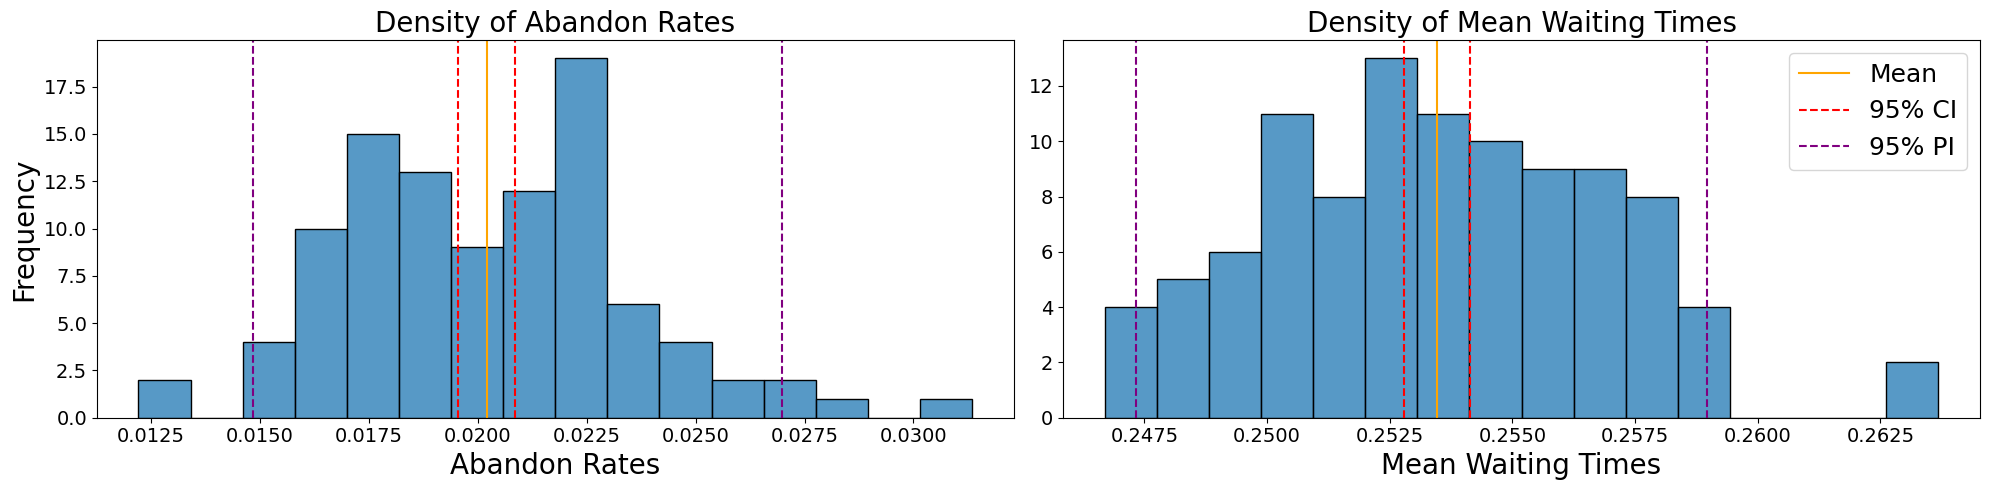

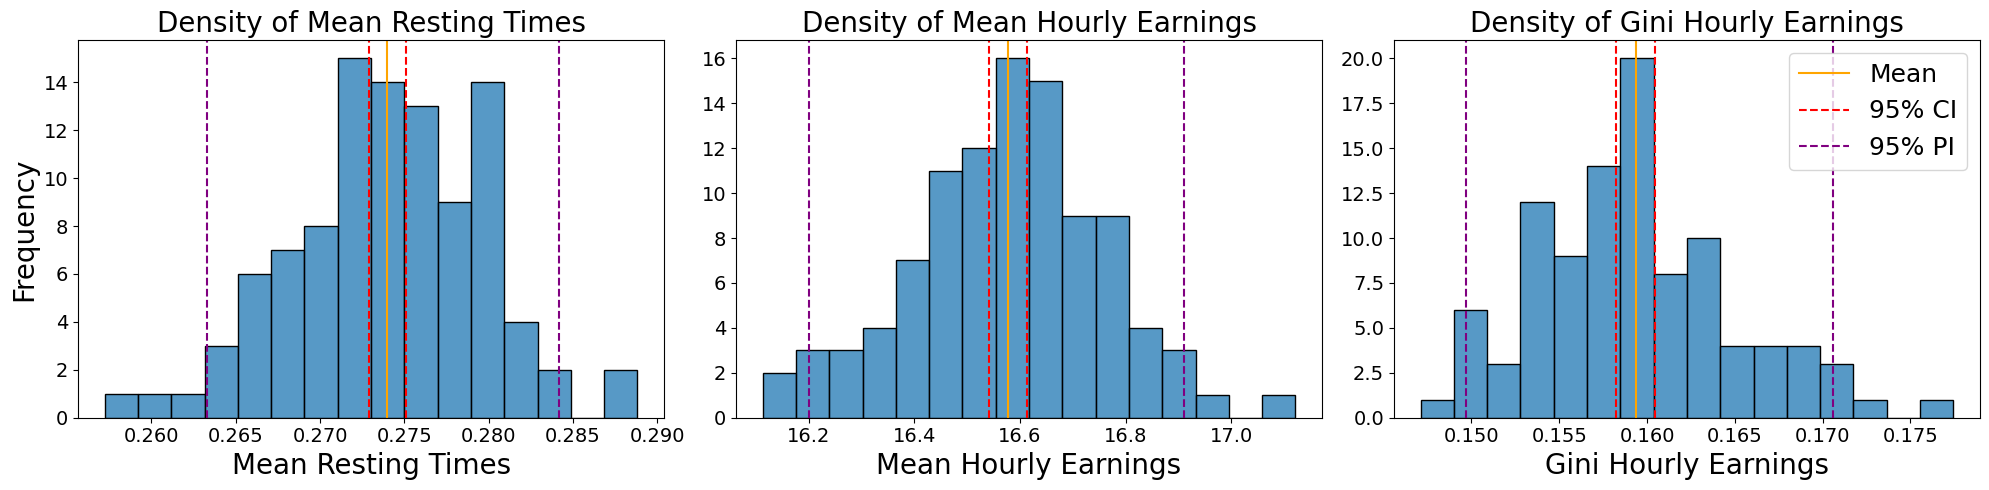

In [13]:
importlib.reload(eval)
# plot histograms of rider and driver metrics
# rider metrics
rider_metrics = all_metrics[0:2]
rider_metric_names = all_metric_names[0:2]
eval.hist_plot(rider_metrics, rider_metric_names, means[0:2], CI_95, PI_95)
# driver metrics
driver_metrics = all_metrics[2:5]
driver_metric_names = all_metric_names[2:5]
eval.hist_plot(driver_metrics, driver_metric_names, means[2:5], CI_95[2:5], PI_95[2:5])


We should now look towards comparing our results with the data given to see how similar our results are.
We should then look into improvements we can make into our model to not only get it to match the data more, but also suggest improvements we could make to the model to provide a better service to both our drivers and riders based on the kpi values

#### Real Data KPI values

In [14]:
importlib.reload(dat)
# find real kpi values
real_kpis = dat.real_kpi_vals(df_drivers, df_riders)

# define as a list for future use
real_abandon_rates = float(real_kpis["abandon_rates"])
mean_real_wait_times = float(np.mean(real_kpis["wait_times"]))
real_kpi_vals = [real_abandon_rates, mean_real_wait_times]
print(f"Abandon rates from given data:", round(real_abandon_rates, 4))
print(f"Mean waiting times from given data:", round(mean_real_wait_times, 4))

Abandon rates from given data: 0.0081
Mean waiting times from given data: 0.2367


Let's compare these KPI values from the real dataset to our bootstrapped simulations

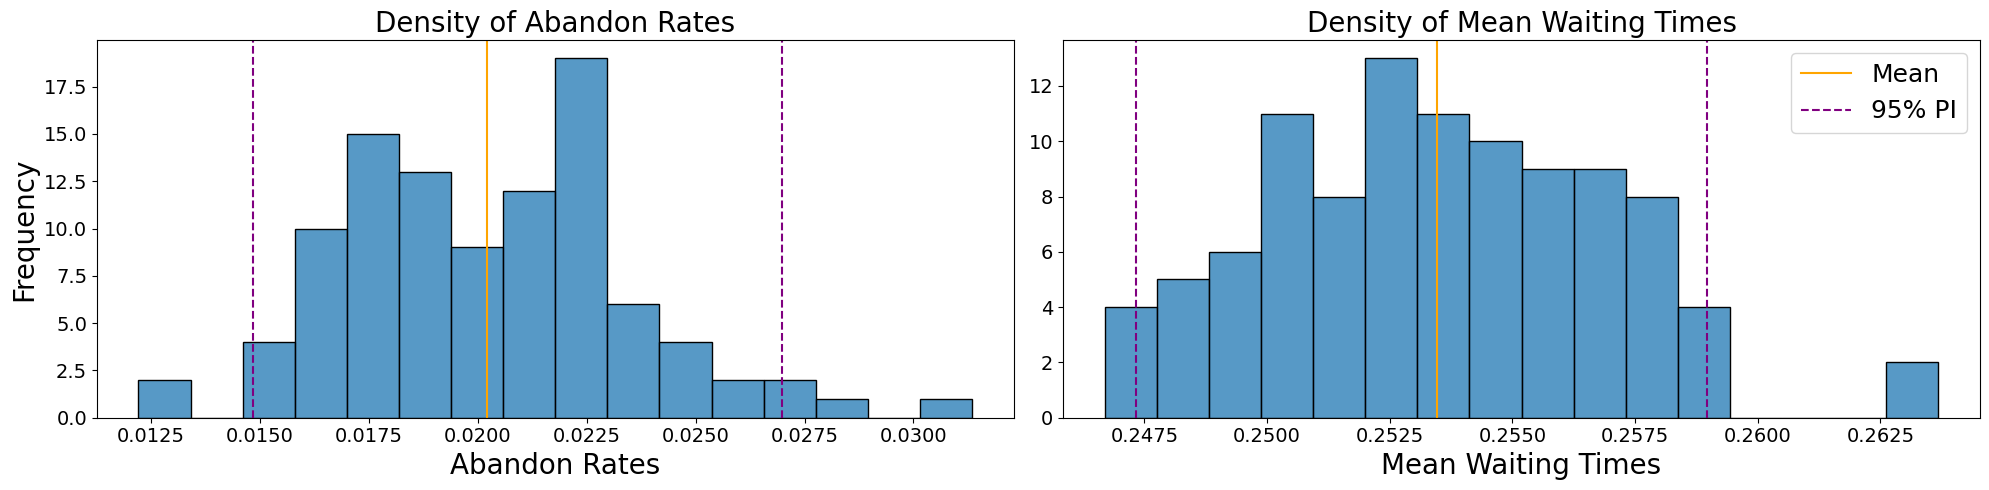

In [15]:
importlib.reload(eval)

# take the metrics we can compare to the real kpi values (abandon rates and mean waiting times)
kpi_sim_comp = all_metrics[:2]
kpi_sim_comp_names = all_metric_names[:2]
kpi_sim_comp_means = means[:2]
kpi_PIs = PI_95[:2]

eval.hist_plot(kpi_sim_comp, kpi_sim_comp_names, means=kpi_sim_comp_means, PIs=kpi_PIs)

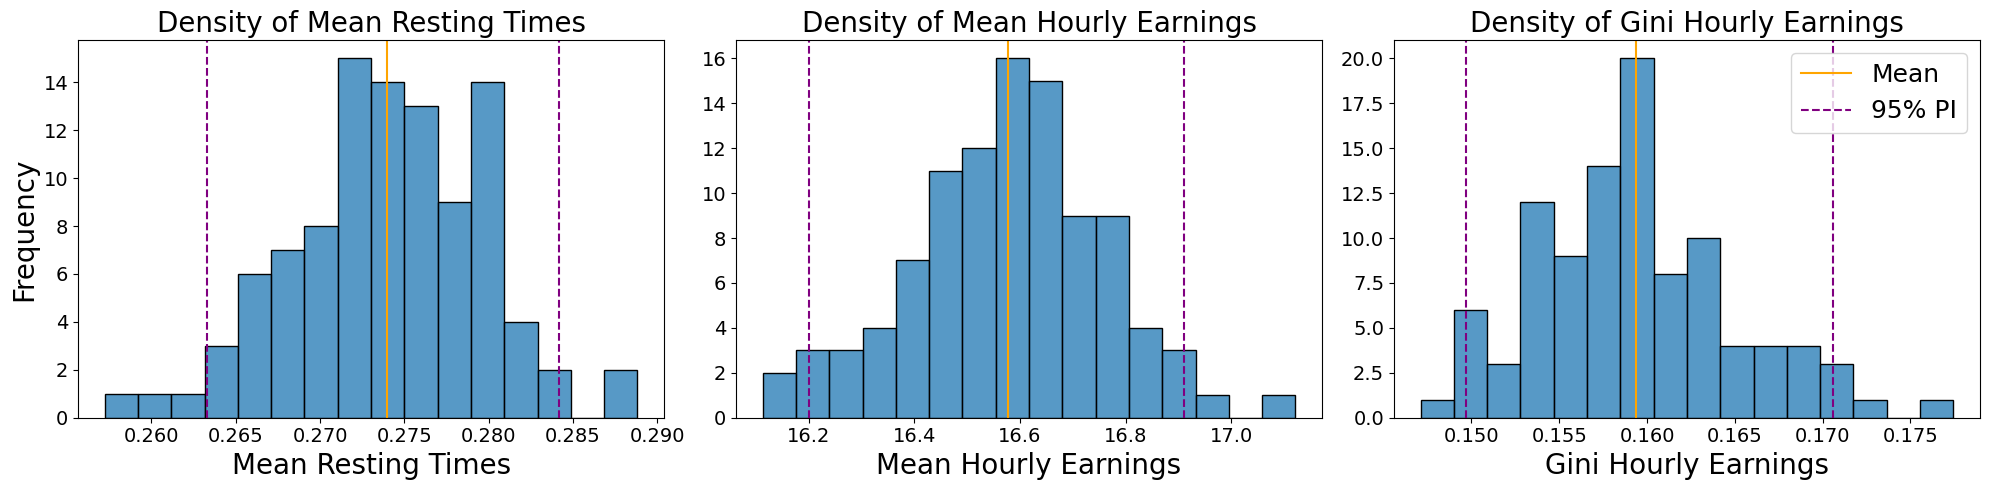

In [16]:
importlib.reload(eval)

# take the metrics we can compare to the real kpi values (abandon rates and mean waiting times)
kpi_sim_comp = all_metrics[2:5]
kpi_sim_comp_names = all_metric_names[2:5]
kpi_sim_comp_means = means[2:5]
kpi_PIs = PI_95[2:5]

eval.hist_plot(kpi_sim_comp, kpi_sim_comp_names, means=kpi_sim_comp_means, PIs=kpi_PIs)

As we can see, our simulation is not similar to the real data given to us by BoxCar.

## Statistical tests used for evaluating distributions

First define a function to calculate the chi-squared assuming uniform(a,b) distribution

In [17]:
import numpy as np
from scipy.stats import chi2

def chi_square_uniform(data, a, b, bins=10):
    """
    Computes chi-squared goodness-of-fit statistic
    for Uniform(a, b) using equal-width bins.

    Parameters
    ----------
    data : array-like
        1D list or numpy array of observations
    a, b : float
        Parameters of Uniform(a, b)
    bins : int
        Number of bins (default = 10)

    Returns
    -------
    chi2_stat : float
    df : int
    p_value : float
    """

    data = np.asarray(data)
    n = len(data)

    # Create equal-width bins between a and b
    bin_edges = np.linspace(a, b, bins + 1)

    # Observed counts
    observed, _ = np.histogram(data, bins=bin_edges)

    # Expected counts (uniform => equal probability per bin)
    expected = np.full(bins, n / bins)

    # Chi-squared statistic
    chi2_stat = np.sum((observed - expected)**2 / expected)

    # Degrees of freedom
    # df = (#bins - 1 - #parameters estimated)
    # If a and b are fixed, no parameters estimated → df = bins - 1
    df = bins - 1

    chi2_critical = chi2.ppf(0.95, df)
    p_value = 1 - chi2.cdf(chi2_stat, df)

    return chi2_stat, chi2_critical, p_value

#### Travel Time

In [18]:
df_riders[df_riders['status']=='abandoned']

,id,request_time,pickup_time,dropoff_time,pickup_location,dropoff_location,status,request_datetime,pickup_datetime,dropoff_datetime
8,9,5.255037,-1.0,-1.0,"(0.3826287569342295, 10.61696663624221)","(11.392973119240452, 10.831182105503926)",abandoned,2025-12-01 13:15:18.133,NaT,NaT
11,12,5.288269,-1.0,-1.0,"(0.7873147698472396, 12.158444752341346)","(7.374601894084525, 14.480021724830495)",abandoned,2025-12-01 13:17:17.770,NaT,NaT
16,17,5.424125,-1.0,-1.0,"(7.399015512490763, 8.357027069570158)","(13.102209657690578, 16.454534763376305)",abandoned,2025-12-01 13:25:26.851,NaT,NaT
20,21,5.453635,-1.0,-1.0,"(7.526778411314254, 19.678465026812283)","(11.143744733135996, 9.641651683787776)",abandoned,2025-12-01 13:27:13.085,NaT,NaT
21,22,5.465138,-1.0,-1.0,"(8.927844179838363, 15.52225564641032)","(10.536582444336602, 6.652280686189634)",abandoned,2025-12-01 13:27:54.497,NaT,NaT
...,...,...,...,...,...,...,...,...,...,...
32938,32939,956.475499,-1.0,-1.0,"(6.126692115197342, 16.521823733358527)","(15.421558798517827, 8.653015722650172)",abandoned,2026-01-10 04:28:31.798,NaT,NaT
32939,32940,956.502766,-1.0,-1.0,"(3.3108014236642926, 12.939966606012337)","(14.121882800574939, 4.675340375893761)",abandoned,2026-01-10 04:30:09.958,NaT,NaT
32941,32942,956.517806,-1.0,-1.0,"(5.187882228983063, 4.229706315244844)","(12.93680544671236, 19.536173632529632)",abandoned,2026-01-10 04:31:04.102,NaT,NaT
34034,34035,988.314693,-1.0,-1.0,"(1.9058093293088074, 15.899457476554348)","(3.9826864587511555, 16.77712620771012)",abandoned,2026-01-11 12:18:52.895,NaT,NaT


In [19]:
df_riders_ = df_riders[(df_riders['status'] != 'dropoff-scheduled') & (df_riders['status'] != 'pickup-scheduled')]

In [20]:
import ast

df_riders_["pickup_location"] = (
    df_riders_["pickup_location"]
    .str.strip("'")                # remove outer single quotes
    .apply(ast.literal_eval)       # convert string to tuple
)

df_riders_["dropoff_location"] = (
    df_riders_["dropoff_location"]
    .str.strip("'")
    .apply(ast.literal_eval)
)

# Extract coordinates
df_riders_["x1"] = df_riders_["pickup_location"].apply(lambda x: x[0])
df_riders_["y1"] = df_riders_["pickup_location"].apply(lambda x: x[1])
df_riders_["x2"] = df_riders_["dropoff_location"].apply(lambda x: x[0])
df_riders_["y2"] = df_riders_["dropoff_location"].apply(lambda x: x[1])

df_riders_matched = df_riders_[df_riders_['status']=="dropped-off"]


# Compute Euclidean distance
df_riders_matched["trip_dist"] = np.sqrt(
    (df_riders_matched["x2"] - df_riders_matched["x1"])**2 +
    (df_riders_matched["y2"] - df_riders_matched["y1"])**2
)

df_riders_matched['trip_duration'] = df_riders_matched['dropoff_time'] - df_riders_matched['pickup_time']
df_riders_matched.head()


,id,request_time,pickup_time,dropoff_time,pickup_location,dropoff_location,status,request_datetime,pickup_datetime,dropoff_datetime,x1,y1,x2,y2,trip_dist,trip_duration
0,1,5.048803,5.372603,5.668817,"(8.52776815255513, 11.374422951736026)","(11.22406718305943, 18.28586415472845)",dropped-off,2025-12-01 13:02:55.690,2025-12-01 13:22:21.370,2025-12-01 13:40:07.743,8.527768,11.374423,11.224067,18.285864,7.418763,0.296215
1,2,5.113495,5.344117,5.658663,"(4.7260253234018075, 13.921168220313202)","(11.219433016467919, 9.224932723238288)",dropped-off,2025-12-01 13:06:48.580,2025-12-01 13:20:38.822,2025-12-01 13:39:31.187,4.726025,13.921168,11.219433,9.224933,8.013674,0.314546
2,3,5.114319,5.819045,6.154474,"(9.34931432850313, 14.855954034601385)","(15.818906976292498, 14.556629597532137)",dropped-off,2025-12-01 13:06:51.547,2025-12-01 13:49:08.563,2025-12-01 14:09:16.107,9.349314,14.855954,15.818907,14.556630,6.476513,0.335429
3,4,5.210384,5.492225,5.915581,"(5.341657715440439, 9.121586876730834)","(11.832789025965816, 11.90864135355879)",dropped-off,2025-12-01 13:12:37.383,2025-12-01 13:29:32.010,2025-12-01 13:54:56.092,5.341658,9.121587,11.832789,11.908641,7.064167,0.423356
4,5,5.229512,5.421566,6.019653,"(5.444067188695589, 13.774420071355813)","(11.208517457838962, 5.792638826367501)",dropped-off,2025-12-01 13:13:46.244,2025-12-01 13:25:17.639,2025-12-01 14:01:10.751,5.444067,13.774420,11.208517,5.792639,9.845695,0.598087


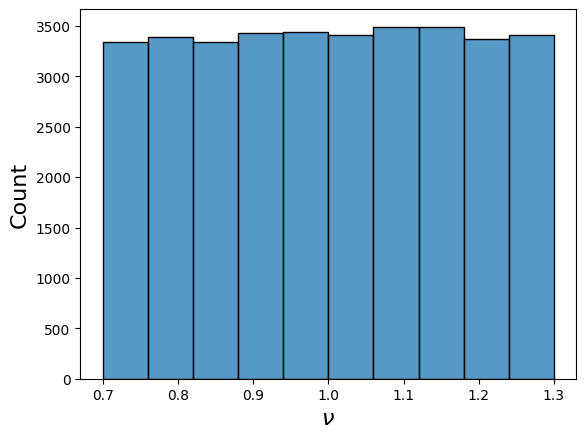

In [21]:
#plt.hist(df_riders_matched['trip_duration']/(df_riders_matched['trip_dist']/20))
sns.histplot(df_riders_matched['trip_duration']/(df_riders_matched['trip_dist']/20), bins=10)
plt.xlabel(r'$\nu$', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.show()

okay, we see clearly this seems uniformly distributed between 0.7,1.3. lets investigate using chi-squared

In [22]:
nu_vals = df_riders_matched['trip_duration']/(df_riders_matched['trip_dist']/20)

In [23]:
a = 0.8
b = 1.2
chi_square_uniform(nu_vals, a, b)

(np.float64(3720.453293079696),
 np.float64(16.918977604620448),
 np.float64(0.0))

#### Uniformity of Driver shift length

In [24]:
df_drivers_ = df_drivers[(df_drivers['status'] != "busy") & (df_drivers['status'] != "available")]

shift_lengths = df_drivers_['offline_time'] - df_drivers_['arrival_time']

In [25]:
a = 5
b = 8
chi_square_uniform(shift_lengths, a, b)

(np.float64(2114.492518170158),
 np.float64(16.918977604620448),
 np.float64(0.0))

#### Exponentiality of interarrival times

In [26]:
intarr_drivers = np.diff(df_drivers_['arrival_time'])
intarr_riders = np.diff(df_riders_['request_time'])

We're gonna use kolmogorov-smirnov test for these as they are continuous distributions

In [27]:
from scipy.stats import kstest

lambda_hat = 1 / np.mean(intarr_drivers)
print(lambda_hat)
D, p_value = kstest(intarr_drivers, 'expon', args=(0, 1/lambda_hat))
print(f"max diff. in cdfs: {D}, p_val: {p_value}")

4.730900764725505
max diff. in cdfs: 0.010670536083372317, p_val: 0.6572374227025982


In [28]:
from scipy.stats import kstest

lambda_hat = 1 / np.mean(intarr_riders)
print(lambda_hat)
D, p_value = kstest(intarr_riders, 'expon', args=(0, 1/lambda_hat))
print(f"max diff. in cdfs: {D}, p_val: {p_value}")

34.57897530032433
max diff. in cdfs: 0.0023216569072362914, p_val: 0.9923073314096296


#### Locations of drivers/riders

In [29]:
chi_square_uniform(df_riders_["y1"], 0, 20)

(np.float64(10928.638330038377),
 np.float64(16.918977604620448),
 np.float64(0.0))

In [30]:
# adjust formatting to extract df_drivers initial locations

df_drivers_["initial_location"] = (
    df_drivers_["initial_location"]
    .str.strip("'")
    .apply(ast.literal_eval)
)

# Extract coordinates
df_drivers_["x"] = df_drivers_["initial_location"].apply(lambda x: x[0])
df_drivers_["y"] = df_drivers_["initial_location"].apply(lambda x: x[1])

In [31]:
chi_square_uniform(df_drivers_["x"], 0, 20)

(np.float64(1097.8999572466867),
 np.float64(16.918977604620448),
 np.float64(0.0))

In [32]:
#df_riders_#[df_riders_['status']=="abandoned"]
df_drivers_

,id,arrival_time,offline_time,initial_location,current_location,status,arrival_datetime,offline_datetime,x,y
0,1,5.011975,11.638223,"(0.7897740952818868, 8.194226996886005)","(13.492895938215721, 17.375090044074234)",offline,2025-12-01 13:00:43.110,2025-12-01 19:38:17.601,0.789774,8.194227
1,2,5.557763,11.732854,"(4.600342938200451, 13.82151625336585)","(13.6809497478333, 15.070060581064372)",offline-scheduled,2025-12-01 13:33:27.947,2025-12-01 19:43:58.273,4.600343,13.821516
2,3,5.661047,12.723458,"(9.09829206926925, 11.669336718393772)","(15.86922281798255, 9.936190354974855)",offline-scheduled,2025-12-01 13:39:39.768,2025-12-01 20:43:24.450,9.098292,11.669337
3,4,5.757413,12.793147,"(14.723720219958555, 14.743429470057318)","(14.232702333916698, 12.939560071816741)",offline-scheduled,2025-12-01 13:45:26.686,2025-12-01 20:47:35.330,14.723720,14.743429
4,5,5.769205,12.431118,"(13.023825947458846, 12.501871643860605)","(19.845683334071563, 7.3885004325174215)",offline-scheduled,2025-12-01 13:46:09.139,2025-12-01 20:25:52.025,13.023826,12.501872
...,...,...,...,...,...,...,...,...,...,...
4674,4675,992.653845,999.680926,"(5.1441690826872914, 11.642130382292915)","(11.629495153845092, 14.58341655096151)",offline-scheduled,2026-01-11 16:39:13.840,2026-01-11 23:40:51.332,5.144169,11.642130
4675,4676,992.939262,999.425327,"(10.454177062819326, 11.94833108013929)","(18.399638378291016, 18.828626884237625)",offline,2026-01-11 16:56:21.344,2026-01-11 23:25:31.178,10.454177,11.948331
4677,4678,993.165653,1000.050162,"(14.283497297158931, 14.573817409922126)","(17.3999773837114, 16.104536543027134)",offline-scheduled,2026-01-11 17:09:56.351,2026-01-12 00:03:00.585,14.283497,14.573817
4679,4680,993.482684,999.883554,"(5.8309527698822485, 5.00621456653222)","(16.02397282373742, 3.1338220244267205)",offline-scheduled,2026-01-11 17:28:57.663,2026-01-11 23:53:00.795,5.830953,5.006215


In [33]:
print(driver_init_x)

NameError: name 'driver_init_x' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm
from scipy.optimize import minimize

def estimate_truncnorm_params(data, lower=0, upper=20):
    def neg_log_likelihood(params):
        mu, sigma = params
        if sigma <= 0:
            return np.inf
        
        a = (lower - mu) / sigma
        b = (upper - mu) / sigma
        
        return -np.sum(truncnorm.logpdf(data, a, b, loc=mu, scale=sigma))
    
    initial_guess = [np.mean(data), np.std(data, ddof=1)]
    result = minimize(neg_log_likelihood, initial_guess)
    
    return result.x  # mu_hat, sigma_hat


def qq_truncnorm_grid(datasets, titles):
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for i, (data, title) in enumerate(zip(datasets, titles)):
        
        mu_hat, sigma_hat = estimate_truncnorm_params(data)
        
        lower, upper = 0, 20
        a = (lower - mu_hat) / sigma_hat
        b = (upper - mu_hat) / sigma_hat
        
        sorted_data = np.sort(data)
        probs = np.linspace(0.01, 0.99, len(data))
        
        theoretical_quantiles = truncnorm.ppf(
            probs, a, b, loc=mu_hat, scale=sigma_hat
        )
        
        ax = axes[i]
        
        # Scatter points
        ax.scatter(
            theoretical_quantiles,
            sorted_data,
            alpha=0.8
        )
        
        # Reference line
        ax.plot(
            [lower, upper],
            [lower, upper],
            color="#8B0000",   # dark red
            linewidth=2
        )
        
        
        ax.set_title(
            f"{title}\n"
            f"$\\mu$={mu_hat:.2f}, $\\sigma$={sigma_hat:.2f}",
            fontsize=16
        )
    
    fig.supxlabel("Theoretical Quantiles", fontsize=16)
    fig.supylabel("Sample Quantiles", fontsize=16)
    plt.tight_layout()
    plt.show()

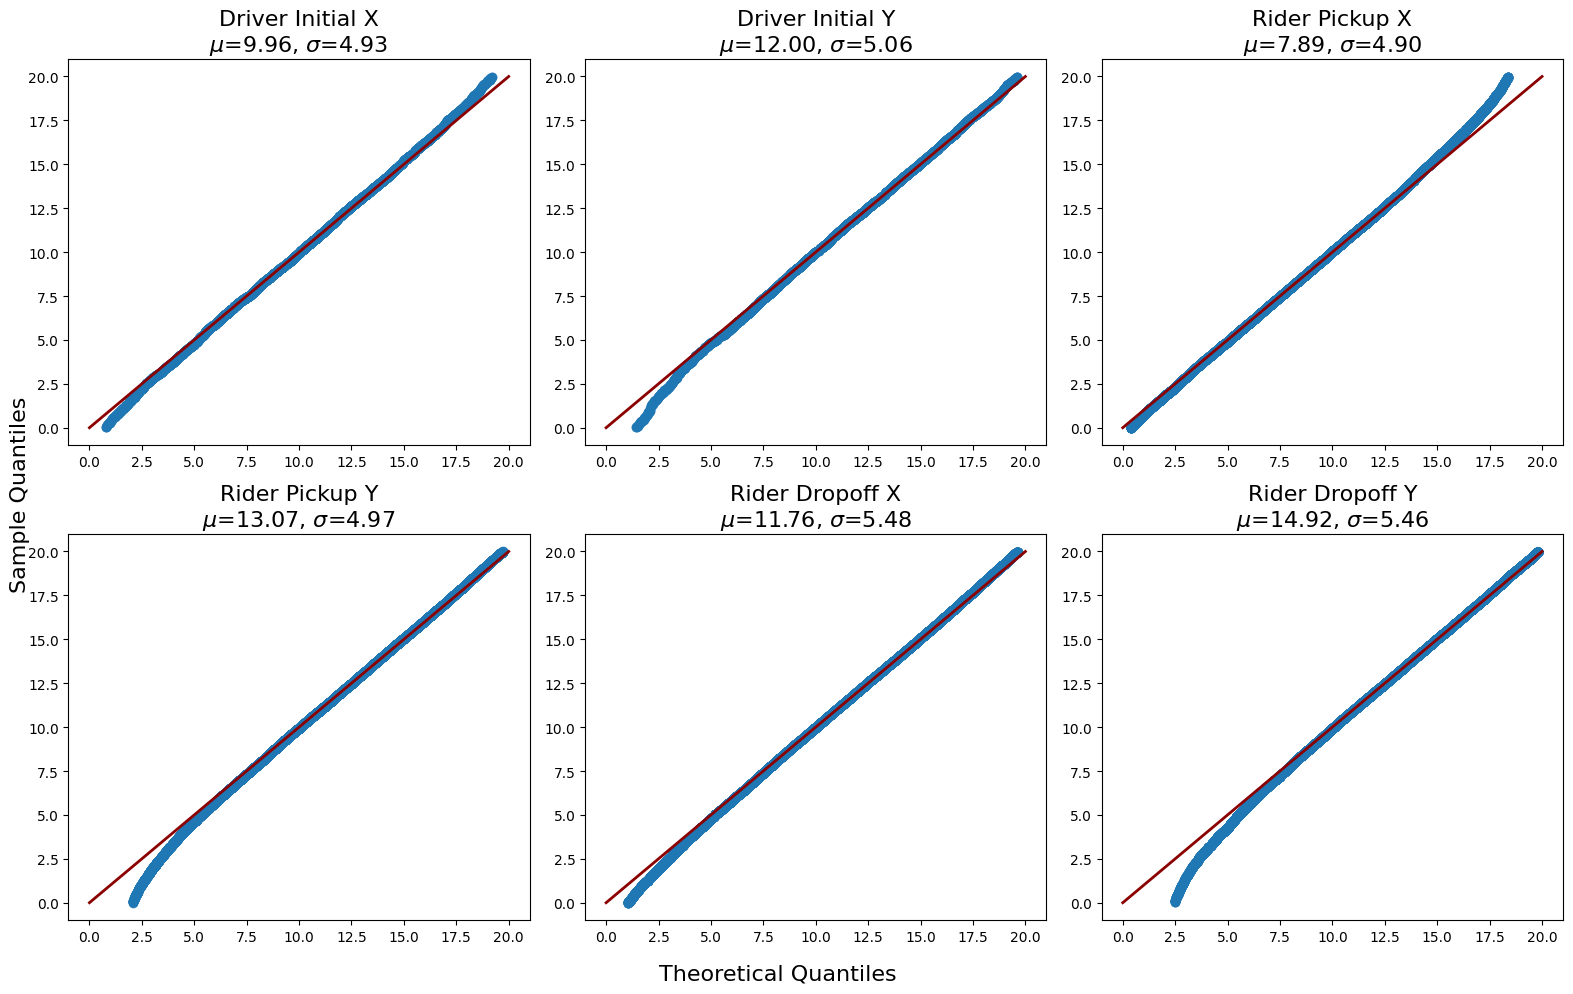

In [ ]:
datasets = [
    df_drivers_["x"],
    df_drivers_["y"],
    df_riders_["x1"],
    df_riders_["y1"],
    df_riders_["x2"],
    df_riders_["y2"],
]

titles = [
    "Driver Initial X",
    "Driver Initial Y",
    "Rider Pickup X",
    "Rider Pickup Y",
    "Rider Dropoff X",
    "Rider Dropoff Y"
]

qq_truncnorm_grid(datasets, titles)

In [ ]:
# now for the ks test
from scipy.stats import truncnorm, kstest
import numpy as np

def norm_test(data, stat_vals):

    mu_hat, sigma_hat = stat_vals
    lower, upper = 0, 20

    a = (lower - mu_hat) / sigma_hat
    b = (upper - mu_hat) / sigma_hat

    u = truncnorm.cdf(data, a, b, loc=mu_hat, scale=sigma_hat)

    D, p_value = kstest(u, 'uniform')

    print("KS statistic:", D)
    print("p-value:", p_value)

print("driver_init")
norm_test(df_drivers_["x"], driver_init_x)
norm_test(df_drivers_["y"], driver_init_y)

print("rider_pickup")
norm_test(df_riders_["x1"], rider_pickup_x)
norm_test(df_riders_["y1"], rider_pickup_y)

print("rider_dropoff")
norm_test(df_riders_["x2"], rider_dropoff_x)
norm_test(df_riders_["y2"], rider_dropoff_y)

driver_init
KS statistic: 0.007661978570434158
p-value: 0.9444642152550018
KS statistic: 0.007014026002631568
p-value: 0.9742354070924981
rider_pickup
KS statistic: 0.0033124691678060314
p-value: 0.8434949881986246
KS statistic: 0.00229902292548112
p-value: 0.9931833279221305
rider_dropoff
KS statistic: 0.0026500587351917515
p-value: 0.9686111683970897
KS statistic: 0.002748640001652869
p-value: 0.9567129378056871


In [ ]:
import statsmodels
from statsmodels.stats.diagnostic import lilliefors

D, p_value = lilliefors(data)
print(f"dist: {D}, pval: {p_value}")

dist: 0.02947856519911307, pval: 0.0009999999999998899


## Testing correlation between pickup and dropoff of riders

In [ ]:
!pip install scipy
from scipy import stats

# Define grid size
bins = 6

# Create grid categories
df_riders_matched['pickup_cell'] = pd.cut(df_riders_matched['x1'], bins=bins).astype(str) + "_" + \
                    pd.cut(df_riders_matched['y1'], bins=bins).astype(str)

df_riders_matched['dropoff_cell'] = pd.cut(df_riders_matched['x2'], bins=bins).astype(str) + "_" + \
                     pd.cut(df_riders_matched['y2'], bins=bins).astype(str)

# Contingency table
cont_table = pd.crosstab(df_riders_matched['pickup_cell'], df_riders_matched['dropoff_cell'])

# Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(cont_table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.6f}")



Chi-square statistic: 1205.24
Degrees of freedom: 1225
p-value: 0.650971
